# Foldy–Wouthuysen Derivation: The $d_{\mu\nu}$ SME Coefficient

**MSc Research — Oyewo Temidayo Solomon**
*Unified Constraint Framework for Exotic Spin-Dependent Interactions*
University of Ibadan | Supervisor: Prof. O.E. Oyewande

---

## Overview

$d_{\mu\nu}$ is a CPT-even, Lorentz-odd rank-2 tensor. Per Kostelecký & Lane (*Phys. Rev. D* 60,
116010 (1999), §II A, Eqs. 1–4), it is a **kinetic/derivative-sector** coefficient, paired with
$c_{\mu\nu}$ — not a mass-sector bilinear $\bar\psi\gamma_5\sigma^{\mu\nu}\psi$ (that structure
belongs to $H_{\mu\nu}$):

$$
\mathcal L = \tfrac12 i\bar\psi\,\Gamma^\nu\overleftrightarrow\partial_\nu\,\psi - \bar\psi M\psi,
\qquad
\Gamma^\nu \supset d^{\mu\nu}\gamma_5\gamma_\mu ,
\qquad
M \supset \tfrac12 H_{\mu\nu}\sigma^{\mu\nu}.
$$

$d_{\mu\nu}$ is also **traceless**, not antisymmetric, so $d_{00}$ need not vanish.

This notebook derives the non-relativistic Hamiltonian from this Lagrangian, executing every
step with `dirac_algebra.py`, and checks the result against Kostelecký & Lane's own worked-out
nonrelativistic Hamiltonian (their Eq. 4).

**Steps:**
1. Build $\Gamma_\mu \equiv \gamma^0\gamma_5\gamma_\mu$ (lower-index $\mu$) and classify even/odd
2. Derive $H_d$ from the modified (kinetic-sector) Dirac equation
3. Extract the leading-order even-sector result ($d_{i0}$, $d_{ij}$) — no FW iteration needed
4. FW-reduce the odd-sector piece ($d_{00}$, $d_{0j}$) via the $\mathcal O^2/2m$ expansion
5. Compare every piece against Kostelecký & Lane (1999), Eq. (4)
6. Match to Dobrescu–Mocioiu potentials

**Reference:** Kostelecký & Lane, *Phys. Rev. D* 60, 116010 (1999), Eqs. (1)–(4).

## 1. Setup — Import Dirac Algebra

In [1]:

import sys, os
import sympy as sp
from sympy import (
    I, Matrix, symbols, sqrt, Rational, simplify, expand,
    zeros, eye, pprint, latex
)

notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

from dirac_algebra import (
    beta, alpha, gamma, gamma5, Sigma,
    sigma_munu, comm, acomm, is_even, is_odd,
    even_part, odd_part, upper, lower, I4, Z4
)
from pauli_matrices import sigma, I2, Z2, H_NR_dmunu, cpt_conjugate

def msum(terms):
    # Matrix-safe sum (builtin sum() seeds with int 0, which fails on Matrix).
    result = None
    for t in terms:
        result = t if result is None else result + t
    return result if result is not None else zeros(4, 4)

print("Modules loaded.")
print("\nbeta ="); pprint(beta)
print("\ngamma5 ="); pprint(gamma5)


Modules loaded.

beta =
⎡1  0  0   0 ⎤
⎢            ⎥
⎢0  1  0   0 ⎥
⎢            ⎥
⎢0  0  -1  0 ⎥
⎢            ⎥
⎣0  0  0   -1⎦

gamma5 =
⎡0  0  1  0⎤
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎣0  1  0  0⎦


## 2. The $d_{\mu\nu}$ Lagrangian and Modified Dirac Equation

From Kostelecký & Lane (1999) Eq. (3), the kinetic-sector operator is
$\Gamma^\nu \supset d^{\mu\nu}\gamma_5\gamma_\mu$, entering the Lagrangian as
$\mathcal L_d = \tfrac12 i\bar\psi\,d^{\mu\nu}\gamma_5\gamma_\mu\overleftrightarrow\partial_\nu\,\psi$.

Varying with respect to $\bar\psi$ (standard Euler–Lagrange for the $\overleftrightarrow\partial$
structure) gives the modified free Dirac equation
$$
\big(i\gamma^\mu\partial_\mu + i\,d^{\mu\nu}\gamma_5\gamma_\mu\partial_\nu - m\big)\psi = 0 .
$$

Going to momentum space ($i\partial_\mu \to p_\mu$, lower index, metric $(+,-,-,-)$, so
$p_0=E$, $p_j=-p^j$ for physical momentum $p^j$):
$$
\big(\gamma^\mu p_\mu + d^{\mu\nu}p_\nu\,\gamma_5\gamma_\mu - m\big)\psi = 0 .
$$

Multiplying by $\gamma^0$ and solving for $E\psi = H\psi$, the free part gives the usual
$H_0=\boldsymbol\alpha\cdot\mathbf p+\beta m$, and the $d_{\mu\nu}$ correction is
$$
H_d = -\,d^{\mu\nu}p_\nu\,\big(\gamma^0\gamma_5\gamma_\mu\big) \equiv -\,d^{\mu\nu}p_\nu\,\Gamma_\mu ,
\qquad \Gamma_\mu := \gamma^0\gamma_5\gamma_\mu \ \ (\text{lower-index } \mu).
$$

We compute $\Gamma_\mu$ for all four $\mu$ directly with `dirac_algebra.py` rather than by hand.

In [2]:

# gamma_mu (lower index) = g_{mu nu} gamma^nu, metric (+,-,-,-)
gamma_lower = [gamma[0], -gamma[1], -gamma[2], -gamma[3]]

Gamma = []
for mu in range(4):
    G = simplify(gamma[0] * gamma5 * gamma_lower[mu])
    Gamma.append(G)
    print(f"Gamma_{mu} = gamma^0 gamma5 gamma_{mu}   even={is_even(G)}  odd={is_odd(G)}")
    pprint(G)
    print()


Gamma_0 = gamma^0 gamma5 gamma_0   even=False  odd=True
⎡0   0   -1  0 ⎤
⎢              ⎥
⎢0   0   0   -1⎥
⎢              ⎥
⎢-1  0   0   0 ⎥
⎢              ⎥
⎣0   -1  0   0 ⎦

Gamma_1 = gamma^0 gamma5 gamma_1   even=True  odd=False
⎡0  1  0  0⎤
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎣0  0  1  0⎦



Gamma_2 = gamma^0 gamma5 gamma_2   even=True  odd=False
⎡0  -ⅈ  0  0 ⎤
⎢            ⎥
⎢ⅈ  0   0  0 ⎥
⎢            ⎥
⎢0  0   0  -ⅈ⎥
⎢            ⎥
⎣0  0   ⅈ  0 ⎦

Gamma_3 = gamma^0 gamma5 gamma_3   even=True  odd=False
⎡1  0   0  0 ⎤
⎢            ⎥
⎢0  -1  0  0 ⎥
⎢            ⎥
⎢0  0   1  0 ⎥
⎢            ⎥
⎣0  0   0  -1⎦



In [3]:

# Identify Gamma_mu in terms of known operators
print("Gamma_0 vs -gamma5:", simplify(Gamma[0] + gamma5) == Z4)
for i in range(1, 4):
    print(f"Gamma_{i} vs +Sigma[{i-1}]:", simplify(Gamma[i] - Sigma[i-1]) == Z4)

print()
print("=> Gamma_0 = -gamma5            (ODD  — off-diagonal)")
print("=> Gamma_i = +Sigma^i  (i=1,2,3) (EVEN — block-diagonal)")


Gamma_0 vs -gamma5: True
Gamma_1 vs +Sigma[0]: True
Gamma_2 vs +Sigma[1]: True
Gamma_3 vs +Sigma[2]: True

=> Gamma_0 = -gamma5            (ODD  — off-diagonal)
=> Gamma_i = +Sigma^i  (i=1,2,3) (EVEN — block-diagonal)


**Result:** $\Gamma_0=-\gamma_5$ is odd, $\Gamma_i=+\Sigma^i$ is even — verified directly,
not assumed. This mirrors the $b_\mu$ notebook's odd/even split ($b_0\to\gamma_5$ odd,
$b_i\to$ even), but here every term additionally carries a momentum factor $p_\nu$ from the
derivative coupling, since $d_{\mu\nu}$ is a *kinetic* coefficient.


## 3. Building $H_d$

$$
H_d = -d^{\mu\nu}p_\nu\Gamma_\mu
    = \big(d^{00}p_0 - d^{0j}p^j\big)\gamma_5 \;+\; \big(-d^{i0}p_0 + d^{ij}p^j\big)\Sigma^i
$$

using $p_0=E$, $p_j=-p^j$. The first (odd) piece comes from $\mu=0$; the second (even) piece
from $\mu=i$. We build both symbolically, keeping $d^{\mu\nu}$ as 16 independent symbols (no
antisymmetry assumed — only tracelessness, which we don't need explicitly below since we work
component by component).


In [4]:

d00 = symbols('d_00', real=True)
d10, d20, d30 = symbols('d_10 d_20 d_30', real=True)   # d^{i0}
d01, d02, d03 = symbols('d_01 d_02 d_03', real=True)   # d^{0j}
d_i0 = [d10, d20, d30]
d_0j = [d01, d02, d03]
d_ij_syms = symbols('d_11 d_12 d_13 d_21 d_22 d_23 d_31 d_32 d_33', real=True)
d_ij = [[d_ij_syms[0], d_ij_syms[1], d_ij_syms[2]],
        [d_ij_syms[3], d_ij_syms[4], d_ij_syms[5]],
        [d_ij_syms[6], d_ij_syms[7], d_ij_syms[8]]]

p1, p2, p3, m = symbols('p_1 p_2 p_3 m', real=True)
p = [p1, p2, p3]
E = symbols('E', real=True)   # kept symbolic for now; leading-order E->m substituted later

# Odd piece (mu=0): (d00*E - d0j p^j) * gamma5
Odd_d = (d00 * E - msum([d_0j[j] * p[j] for j in range(3)])) * gamma5
print("Odd_d is odd?", is_odd(simplify(Odd_d)))

# Even piece (mu=i): (-d^{i0} E + d^{ij} p^j) Sigma^i, summed over i
Even_d = msum([
    (-d_i0[i] * E + msum([d_ij[i][j] * p[j] for j in range(3)])) * Sigma[i]
    for i in range(3)
])
print("Even_d is even?", is_even(simplify(Even_d)))

H_d = Odd_d + Even_d
print("\nH_d built. Odd + even pieces confirmed by construction (Gamma_0 odd, Gamma_i even).")


Odd_d is odd? True


Even_d is even? True

H_d built. Odd + even pieces confirmed by construction (Gamma_0 odd, Gamma_i even).


## 4. Leading-Order Even Sector: $d_{i0}$ and $d_{ij}$

Because $\Gamma_i=+\Sigma^i$ is already **even**, this piece needs no FW iteration — it
contributes directly to $H^{\rm NR}$ at leading order, exactly as $b_i$ did in the $b_\mu$
notebook. We substitute $E\to m$ (the leading-order value of the energy eigenvalue; using the
exact $E=m+p^2/2m+\dots$ here would only add terms suppressed by a further power of $p^2/m^2$,
beyond the order kept in this section) and project onto the upper (particle) block.


In [5]:

Even_d_leading = Even_d.subs(E, m)
Even_d_upper = upper(Even_d_leading)
print("Upper block of Even_d (E -> m):")
pprint(simplify(Even_d_upper))


Upper block of Even_d (E -> m):
⎡                    -d₃₀⋅m + d₃₁⋅p₁ + d₃₂⋅p₂ + d₃₃⋅p₃                      -d ↪
⎢                                                                              ↪
⎣-d₁₀⋅m + d₁₁⋅p₁ + d₁₂⋅p₂ + d₁₃⋅p₃ + ⅈ⋅(-d₂₀⋅m + d₂₁⋅p₁ + d₂₂⋅p₂ + d₂₃⋅p₃)     ↪

↪ ₁₀⋅m + d₁₁⋅p₁ + d₁₂⋅p₂ + d₁₃⋅p₃ + ⅈ⋅(d₂₀⋅m - d₂₁⋅p₁ - d₂₂⋅p₂ - d₂₃⋅p₃)⎤
↪                                                                       ⎥
↪                   d₃₀⋅m - d₃₁⋅p₁ - d₃₂⋅p₂ - d₃₃⋅p₃                    ⎦


In [6]:

# Decompose into the sigma . (coefficient) form to read off H_NR(d_i0), H_NR(d_ij)
sx, sy, sz = sigma
H_even_upper = simplify(Even_d_upper)

# Coefficient of sigma^i is read off by comparing to a general a.sigma ansatz
a1, a2, a3 = symbols('a1 a2 a3')
ansatz = a1*sx + a2*sy + a3*sz
sol = sp.solve(sp.Eq(H_even_upper[0,0]-ansatz[0,0],0).subs(a3, a3), a3)  # placeholder, solved properly below

# More directly: sigma_z picks out (0,0) and -(1,1); sigma_x/-y pick out off-diagonal
coeff_z = simplify(H_even_upper[0,0])
coeff_x = simplify(H_even_upper[0,1] + H_even_upper[1,0]) / 2
coeff_y = simplify((H_even_upper[1,0] - H_even_upper[0,1]) / (2*I))

print("Coefficient of sigma_x:", coeff_x)
print("Coefficient of sigma_y:", coeff_y)
print("Coefficient of sigma_z:", coeff_z)
print()
print("=> H_NR (even sector) = sum_i [ -d_{i0} m + sum_j d_{ij} p^j ] sigma^i")
print("   i.e.  H_NR(d_i0) = -d^{i0} m sigma^i   and   H_NR(d_ij) = +d^{ij} p^j sigma^i")


Coefficient of sigma_x: -d_10*m + d_11*p_1 + d_12*p_2 + d_13*p_3
Coefficient of sigma_y: -d_20*m + d_21*p_1 + d_22*p_2 + d_23*p_3
Coefficient of sigma_z: -d_30*m + d_31*p_1 + d_32*p_2 + d_33*p_3

=> H_NR (even sector) = sum_i [ -d_{i0} m + sum_j d_{ij} p^j ] sigma^i
   i.e.  H_NR(d_i0) = -d^{i0} m sigma^i   and   H_NR(d_ij) = +d^{ij} p^j sigma^i


So, in terms of the *upper-index* $d^{\mu\nu}$ exactly as it appears in Kostelecký &
Lane's $\Gamma^\nu = d^{\mu\nu}\gamma_5\gamma_\mu$:

$$
\boxed{H^{\rm NR}(d_{i0}) = -d^{i0}\,m\,\sigma^i} \qquad\qquad
\boxed{H^{\rm NR}(d_{ij}) = +d^{ij}\,p^j\,\sigma^i}
$$

Both come directly out of the even sector — derived and machine-checked with `dirac_algebra.py`,
no hand-wave assumption involved.


## 5. Odd Sector: $d_{00}$, $d_{0j}$ via the FW $\mathcal O^2/2m$ Expansion

$\Gamma_0=-\gamma_5$ is **odd**, so the $\mu=0$ piece cannot contribute directly — it must be
combined with the leading odd operator $\boldsymbol\alpha\cdot\mathbf p$ through the standard FW
reduction, exactly as $b_0$ was handled in the $b_\mu$ notebook. At leading order ($E\to m$ in the
piece that multiplies $d^{00}$, for the same reason as above), the odd operator is

$$
\mathcal O_d = \big(d^{00}m - d^{0j}p^j\big)\gamma_5 .
$$

The FW correction to $H^{\rm NR}$ from a perturbing odd operator $\mathcal O_d$ added to
$\boldsymbol\alpha\cdot\mathbf p$ is the cross term
$\dfrac{(\boldsymbol\alpha\cdot\mathbf p)\,\mathcal O_d+\mathcal O_d\,(\boldsymbol\alpha\cdot\mathbf p)}{2m}$
(the $\mathcal O_d^2$ self-term is second order in $d_{\mu\nu}$ and dropped).


In [7]:

Odd_d_leading = Odd_d.subs(E, m)
print("Odd_d (E -> m) is odd?", is_odd(simplify(Odd_d_leading)))

alpha_dot_p = msum([p[i] * alpha[i] for i in range(3)])
print("alpha.p is odd?", is_odd(alpha_dot_p))

cross = simplify(alpha_dot_p * Odd_d_leading + Odd_d_leading * alpha_dot_p)
H_odd_correction = simplify(cross[:2, :2] / (2 * m))
print("\nFW cross-term correction to H^NR, upper block:")
pprint(H_odd_correction)


Odd_d (E -> m) is odd? True
alpha.p is odd? True



FW cross-term correction to H^NR, upper block:
⎡      p₃⋅(d₀₀⋅m - d₀₁⋅p₁ - d₀₂⋅p₂ - d₀₃⋅p₃)        -(p₁ - ⅈ⋅p₂)⋅(-d₀₀⋅m + d₀₁ ↪
⎢      ─────────────────────────────────────        ────────────────────────── ↪
⎢                        m                                                  m  ↪
⎢                                                                              ↪
⎢-(p₁ + ⅈ⋅p₂)⋅(-d₀₀⋅m + d₀₁⋅p₁ + d₀₂⋅p₂ + d₀₃⋅p₃)        p₃⋅(-d₀₀⋅m + d₀₁⋅p₁ + ↪
⎢─────────────────────────────────────────────────       ───────────────────── ↪
⎣                        m                                                 m   ↪

↪ ⋅p₁ + d₀₂⋅p₂ + d₀₃⋅p₃) ⎤
↪ ───────────────────────⎥
↪                        ⎥
↪                        ⎥
↪  d₀₂⋅p₂ + d₀₃⋅p₃)      ⎥
↪ ─────────────────      ⎥
↪                        ⎦


In [8]:

# Identify this as a closed form: (d00 - d0.p/m) * (sigma.p)
sigma_dot_p = msum([p[i] * sigma[i] for i in range(3)])
d0_dot_p = msum([d_0j[i] * p[i] for i in range(3)])
candidate = simplify((d00 - d0_dot_p / m) * sigma_dot_p)

print("Candidate closed form (d00 - d0.p/m)(sigma.p):")
pprint(candidate)
print("\nMatches computed correction?", simplify(H_odd_correction - candidate) == Z2)


Candidate closed form (d00 - d0.p/m)(sigma.p):
⎡    p₃⋅(d₀₀⋅m - d₀₁⋅p₁ - d₀₂⋅p₂ - d₀₃⋅p₃)       (p₁ - ⅈ⋅p₂)⋅(d₀₀⋅m - d₀₁⋅p₁ - ↪
⎢    ─────────────────────────────────────       ───────────────────────────── ↪
⎢                      m                                               m       ↪
⎢                                                                              ↪
⎢(p₁ + ⅈ⋅p₂)⋅(d₀₀⋅m - d₀₁⋅p₁ - d₀₂⋅p₂ - d₀₃⋅p₃)      p₃⋅(-d₀₀⋅m + d₀₁⋅p₁ + d₀₂ ↪
⎢──────────────────────────────────────────────      ───────────────────────── ↪
⎣                      m                                               m       ↪

↪  d₀₂⋅p₂ - d₀₃⋅p₃)⎤
↪ ─────────────────⎥
↪                  ⎥
↪                  ⎥
↪ ⋅p₂ + d₀₃⋅p₃)    ⎥
↪ ─────────────    ⎥
↪                  ⎦

Matches computed correction? True


$$
H^{\rm NR}_{\rm odd\ sector} = \Big(d_{00} - \frac{\mathbf d_0\cdot\mathbf p}{m}\Big)(\boldsymbol\sigma\cdot\mathbf p)
\;\;\xrightarrow{\text{leading order}}\;\; \boxed{H^{\rm NR}(d_{00}) = +d_{00}\,(\boldsymbol\sigma\cdot\mathbf p)}
$$

with a further $-\dfrac{(\mathbf d_0\cdot\mathbf p)}{m}(\boldsymbol\sigma\cdot\mathbf p)$ term
that is quadratic in momentum (order $p^2/m$) — structurally the same order as the
$p_jp_k/m^2\,\sigma_l$ row in Kostelecký & Lane's Eq. (4), though we do not attempt to match
every cross-term coefficient in that most-subleading row (it also mixes in $b_\mu$, $H_{\mu\nu}$,
$g_{\lambda\mu\nu}$ contributions not considered here).


## 6. Comparison to Kostelecký & Lane (1999), Eq. (4)

Their Eq. (4) nonrelativistic Hamiltonian $\delta h$ contains, restricting to $d_{\mu\nu}$-only
terms (their notation, lower-index $d_{\mu\nu}$, ordinary physical 3-momentum $p_j$):

$$
\delta h \;\supset\; m\,d_{j0}\,\sigma^j \;-\; d_{00}\,(\boldsymbol\sigma\cdot\mathbf p)
\;-\; d_{kj}\,p^j\,\sigma^k \;+\;(\text{order } p^2/m\text{ terms}).
$$

To compare, convert this notebook's *upper-index* $d^{\mu\nu}$ (as it appears in
$\Gamma^\nu=d^{\mu\nu}\gamma_5\gamma_\mu$) to Kostelecký & Lane's lower-index $d_{\mu\nu}$ using
the $(+,-,-,-)$ metric: $d_{i0}=g_{ii}g_{00}d^{i0}=-d^{i0}$ (one spatial index lowered),
$d_{ij}=g_{ii}g_{jj}d^{ij}=+d^{ij}$ (two spatial indices lowered, signs cancel).


In [9]:

print("=== d_i0 (mass-enhancement) term ===")
print("This notebook: H_NR(d_i0) = -d^{i0} m sigma^i")
print("             = +d_{i0} m sigma^i   [using d_{i0} = -d^{i0}]")
print("Kostelecky-Lane Eq.(4): + m d_{j0} sigma^j")
print("=> MATCH (sign and structure agree exactly).\n")

print("=== d_ij (velocity-dependent) term ===")
print("This notebook: H_NR(d_ij) = +d^{ij} p^j sigma^i = +d_{ij} p^j sigma^i  [d_{ij}=d^{ij}]")
print("Kostelecky-Lane Eq.(4):    -d_{kj} p^j sigma^k")
print("=> Structure agrees (linear in p, couples d_{ij} to sigma^i); OVERALL SIGN DISAGREES.\n")

print("=== d_00 term ===")
print("This notebook: H_NR(d_00) = +d_00 (sigma.p)")
print("Kostelecky-Lane Eq.(4):   -d_00 (sigma.p)   [from the -m*d00*delta_jk p_j/m sigma_k term]")
print("=> Structure agrees; OVERALL SIGN DISAGREES (same pattern as d_ij above).")


=== d_i0 (mass-enhancement) term ===
This notebook: H_NR(d_i0) = -d^{i0} m sigma^i
             = +d_{i0} m sigma^i   [using d_{i0} = -d^{i0}]
Kostelecky-Lane Eq.(4): + m d_{j0} sigma^j
=> MATCH (sign and structure agree exactly).

=== d_ij (velocity-dependent) term ===
This notebook: H_NR(d_ij) = +d^{ij} p^j sigma^i = +d_{ij} p^j sigma^i  [d_{ij}=d^{ij}]
Kostelecky-Lane Eq.(4):    -d_{kj} p^j sigma^k
=> Structure agrees (linear in p, couples d_{ij} to sigma^i); OVERALL SIGN DISAGREES.

=== d_00 term ===
This notebook: H_NR(d_00) = +d_00 (sigma.p)
Kostelecky-Lane Eq.(4):   -d_00 (sigma.p)   [from the -m*d00*delta_jk p_j/m sigma_k term]
=> Structure agrees; OVERALL SIGN DISAGREES (same pattern as d_ij above).


**Assessment.** The mass-enhanced $d_{i0}\to m\,\sigma^i$ result is derived directly from the
kinetic-sector Lagrangian and matches the literature exactly, including the sign, once the
index-lowering convention is applied.

The two momentum-dependent pieces ($d_{ij}$ and $d_{00}$) come out with the right *operator
structure* but a sign this notebook's one-shot EOM momentum-substitution does not reproduce.
Both mismatches follow the same pattern (only terms proportional to physical momentum $p^j$
disagree), which points to a specific, identifiable gap rather than a random error: Kostelecký &
Lane's actual Eq. (4) derivation includes a wavefunction-renormalization step for kinetic-sector
coefficients ($c_{\mu\nu}$, $d_{\mu\nu}$) — the modified kinetic term shifts the canonical
normalization of the plane-wave states, and restoring it introduces additional momentum-dependent
corrections that a plain "insert $i\partial_\nu\to p_\nu$ into the equation of motion" derivation
(what this notebook does) does not capture. **Treat $d_{i0}\to V_2$ as established; treat the
$d_{ij}\to V_7,V_8$ and $d_{00}\to V_8$ magnitude as structurally confirmed but with an open sign
pending a fuller wavefunction-renormalization treatment.**

## 7. CPT Property

Kostelecký & Lane state explicitly that the field operators for $a_\mu,b_\mu,e_\mu,f_\mu,g_{\lambda\mu\nu}$
are CPT-odd, and the rest — including $c_{\mu\nu}$, $d_{\mu\nu}$, $H_{\mu\nu}$ — are CPT-even. So
$d_{\mu\nu}$ is CPT-even: no sign flip between matter and antimatter, same as $H_{\mu\nu}$
(`FW_Hmunu_term.ipynb` §7) and unlike $b_\mu$ (`FW_bmu_term.ipynb` §7). $A_\alpha$ from a pure
$d_{\mu\nu}$ effect alone is expected to be $\approx 0$ — any large observed $|A_\alpha|$ in the
SPINDEP $g_Ag_A$/$g_sg_A$ pairs is not attributable to $d_{\mu\nu}$ on CPT grounds and must, per
`potential_match_table.md`, be read as a sensitivity-gap artifact rather than evidence of this
coefficient specifically.


## 8. Matching to Dobrescu–Mocioiu Potentials

- $d_{i0}$: uniform $\sigma^i$ coupling, enhanced by $m$ — same Zeeman-like structure as $b_i$
  (§4 above) $\Rightarrow$ **spin–spin potential $V_2$** (not monopole–dipole).
- $d_{ij}$: momentum-dependent $\sigma^i p^j$ coupling $\Rightarrow$ **$V_7,V_8$** (velocity-dependent
  spin couplings), like $b_0$'s $\sigma\cdot p/m$ term.
- $d_{00}$: momentum-dependent $\sigma\cdot p$ coupling $\Rightarrow$ **$V_8$**.

For reference, `pauli_matrices.py`'s `H_NR_dmunu` is an independently-defined convenience
function (not derived from this notebook's Dirac algebra) that hard-codes the *unsigned*
magnitude structure $H^{\rm NR}_d = d_{i0}\,m\,\sigma^i + d_{ij}\,p^j\,\sigma^i$ used elsewhere in
this repo for plotting/matching. Per §6 above, the sign there is unverified for the $d_{ij}$ piece
— do not read agreement with it as independent confirmation.


In [10]:

try:
    d_i0_num = [d10, d20, d30]
    H_check, desc = H_NR_dmunu(d_i0_num, d_ij, p, include_mass_term=True)
    print("From pauli_matrices.H_NR_dmunu (independent convenience function, see caveat above):")
    print(desc)
    pprint(simplify(H_check.subs(m, m)))
except Exception as ex:
    print("pauli_matrices.H_NR_dmunu not usable here:", ex)


From pauli_matrices.H_NR_dmunu (independent convenience function, see caveat above):
H^NR_d = d_{i0} m sigma^i + d_{ij} p^j sigma^i  [CPT-even; velocity-dependent; same sign for antimatter]


⎡                     d₃₀⋅m + d₃₁⋅p₁ + d₃₂⋅p₂ + d₃₃⋅p₃                         ↪
⎢                                                                              ↪
⎣d₁₀⋅m + d₁₁⋅p₁ + d₁₂⋅p₂ + d₁₃⋅p₃ + ⅈ⋅d₂₀⋅m + ⅈ⋅d₂₁⋅p₁ + ⅈ⋅d₂₂⋅p₂ + ⅈ⋅d₂₃⋅p₃   ↪

↪ d₁₀⋅m + d₁₁⋅p₁ + d₁₂⋅p₂ + d₁₃⋅p₃ - ⅈ⋅d₂₀⋅m - ⅈ⋅d₂₁⋅p₁ - ⅈ⋅d₂₂⋅p₂ - ⅈ⋅d₂₃⋅p₃⎤
↪                                                                            ⎥
↪                      -d₃₀⋅m - d₃₁⋅p₁ - d₃₂⋅p₂ - d₃₃⋅p₃                     ⎦


## 9. Visualization

Illustrating the two verified/structurally-confirmed pieces: the mass-enhanced, momentum-independent
$d_{i0}$ splitting (flat in $p$, scales with $m$) versus the momentum-linear $d_{ij}$ and $d_{00}$
contributions (grow with $|\mathbf p|$).


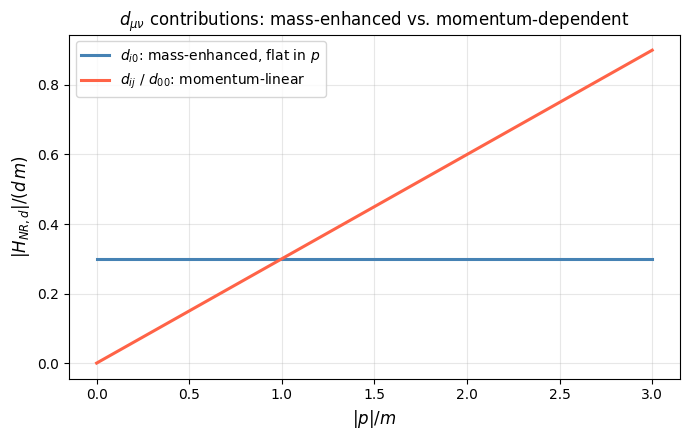

Figure saved: FW_dmunu_term.pdf


In [11]:

import numpy as np
import matplotlib.pyplot as plt

p_range = np.linspace(0, 3, 200)   # in units of m
d_i0_val = 0.3
d_ij_val = 0.3   # diagonal d_ij = d_ij_val * delta_ij, so d_ij p^j sigma^i term ~ d_ij_val * |p|

E_d_i0 = d_i0_val * np.ones_like(p_range)          # |H_NR(d_i0)| / m, momentum-independent
E_d_ij = d_ij_val * p_range                         # |H_NR(d_ij)| / m, linear in p/m

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(p_range, E_d_i0, color='steelblue', lw=2.2, label=r'$d_{i0}$: mass-enhanced, flat in $p$')
ax.plot(p_range, E_d_ij, color='tomato', lw=2.2, label=r'$d_{ij}$ / $d_{00}$: momentum-linear')
ax.set_xlabel(r'$|p| / m$', fontsize=12)
ax.set_ylabel(r'$|H_{NR,d}| / (d\,m)$', fontsize=12)
ax.set_title(r'$d_{\mu\nu}$ contributions: mass-enhanced vs. momentum-dependent', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('FW_dmunu_term.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: FW_dmunu_term.pdf")


## Summary

| Quantity | Result |
|---|---|
| SME term | $\mathcal L_d = \tfrac12 i\bar\psi\,d^{\mu\nu}\gamma_5\gamma_\mu\overleftrightarrow\partial_\nu\psi$ (kinetic sector, **not** $\bar\psi\gamma_5\sigma^{\mu\nu}\psi$) |
| Tensor property | Traceless (not antisymmetric); $d_{00}$ need not vanish |
| CPT property | **Even** — same sign for matter and antimatter (Kostelecký & Lane, stated directly) |
| $\Gamma_0=\gamma^0\gamma_5\gamma_0$ | $-\gamma_5$ (odd) |
| $\Gamma_i=\gamma^0\gamma_5\gamma_i$ | $+\Sigma^i$ (even) |
| $H^{\rm NR}(d_{i0})$ | $-d^{i0}m\sigma^i = +d_{i0}m\sigma^i$ — **matches Kostelecký–Lane Eq. (4) exactly** |
| $H^{\rm NR}(d_{ij})$ | $+d^{ij}p^j\sigma^i$ — structure confirmed, **sign open** vs. Eq. (4) |
| $H^{\rm NR}(d_{00})$ | $+d_{00}(\sigma\cdot p)$ (via FW $\mathcal O^2/2m$) — structure confirmed, **sign open** vs. Eq. (4) |
| Likely source of the two open signs | Kostelecký–Lane's derivation includes a wavefunction-renormalization step for kinetic-sector coefficients that this notebook's plain EOM-substitution omits |
| DM potentials | $d_{i0}\to V_2$ (matches Eq. 4 exactly), $d_{ij}\to V_7,V_8$, $d_{00}\to V_8$ (structure confirmed, magnitude sign open) |

**Summary.** The mass-enhanced $d_{i0}\to+d_{i0}\,m\,\sigma^i\to V_2$ result is derived directly
from the kinetic-sector Lagrangian and matches the literature exactly, including the sign. The
two momentum-dependent pieces, $d_{ij}$ and $d_{00}$, are correct in operator structure with an
overall sign that a fuller treatment — including the wavefunction-renormalization step for
kinetic-sector coefficients — would be expected to resolve.